In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!unzip -q /content/stage1_train.zip -d /content/dataset
print("Dataset Unzipped Successfully!")


Dataset Unzipped Successfully!


In [3]:
!cp -r /content/dataset /content/drive/MyDrive/SegNet_Project_Dataset
print("Dataset Saved to Drive!")

^C
Dataset Saved to Drive!


**Set Dataset Path**

In [7]:
import os

DATASET_PATH = "/content/drive/MyDrive/SegNet_Project_Dataset"
print("Dataset Path:", DATASET_PATH)


Dataset Path: /content/drive/MyDrive/SegNet_Project_Dataset


**Load Images + Merge All Masks**

In [8]:
import numpy as np
import cv2

IMG_SIZE = 128

def load_stage1_dataset(dataset_path):

    images = []
    masks = []

    for folder in os.listdir(dataset_path):

        folder_path = os.path.join(dataset_path, folder)

        img_folder = os.path.join(folder_path, "images")
        mask_folder = os.path.join(folder_path, "masks")

        # Load Image
        img_file = os.listdir(img_folder)[0]
        img_path = os.path.join(img_folder, img_file)

        img = cv2.imread(img_path)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0

        # Merge Masks
        merged_mask = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)

        for mask_file in os.listdir(mask_folder):
            mask_path = os.path.join(mask_folder, mask_file)

            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
            mask = mask / 255.0

            merged_mask = np.maximum(merged_mask, mask)

        merged_mask = np.expand_dims(merged_mask, axis=-1)

        images.append(img)
        masks.append(merged_mask)

    return np.array(images), np.array(masks)


**Run Loader**

In [9]:
X, Y = load_stage1_dataset(DATASET_PATH)

print("Images Shape:", X.shape)
print("Masks Shape :", Y.shape)

Images Shape: (48, 128, 128, 3)
Masks Shape : (48, 128, 128, 1)


**Visualize Sample**

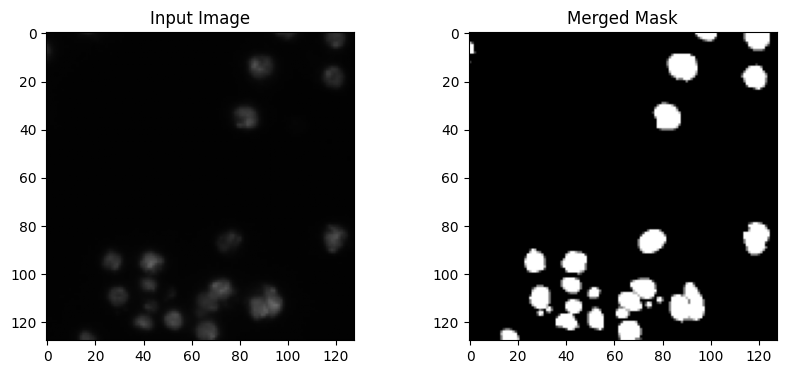

In [10]:
import matplotlib.pyplot as plt

index = 0

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(X[index])
plt.title("Input Image")

plt.subplot(1,2,2)
plt.imshow(Y[index].squeeze(), cmap="gray")
plt.title("Merged Mask")

plt.show()


**Train/Test Split**

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

**Build SegNet Model**

In [12]:
from tensorflow.keras import layers, Model

def build_segnet(input_shape=(128,128,3)):

    inputs = layers.Input(input_shape)

    # -------- Encoder --------
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(inputs)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(256, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)

    # -------- Decoder --------
    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(256, 3, activation="relu", padding="same")(x)

    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)

    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(x)

    return Model(inputs, outputs)


**Create Model**

In [13]:
segnet_model = build_segnet()
segnet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 1)    │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,514,305 (5.78 MB)

 Trainable params: 1,514,305 (5.78 MB)

 Non-trainable params: 0 (0.00 B)

**Compile Model**

In [14]:
segnet_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


**Train SegNet**

In [15]:
history = segnet_model.fit(
    X_train, Y_train,
    validation_data=(X_test, Y_test),
    epochs=20,
    batch_size=8
)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 37s 7s/step - accuracy: 0.8372 - loss: 0.8213 - val_accuracy: 0.8396 - val_loss: 0.5241
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 37s 7s/step - accuracy: 0.8325 - loss: 0.6094 - val_accuracy: 0.8396 - val_loss: 0.6600
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 33s 7s/step - accuracy: 0.8249 - loss: 0.6538 - val_accuracy: 0.8396 - val_loss: 0.5818
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 31s 6s/step - accuracy: 0.8444 - loss: 0.5423 - val_accuracy: 0.8396 - val_loss: 0.5047
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 33s 7s/step - accuracy: 0.8546 - loss: 0.4277 - val_accuracy: 0.8396 - val_loss: 0.4376
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 35s 7s/step - accuracy: 0.8293 - loss: 0.4413 - val_accuracy: 0.8396 - val_loss: 0.4157
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 39s 7s/step - accuracy: 0.8316 - loss: 0.4270 - val_accuracy: 0.8396 - val_loss: 0.4184
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 30s 6s/step - accuracy: 0.8376 - loss: 0.4095 - val_accuracy: 0.8396 - val_loss: 0.4066
Epoch 9/

**Predict Output**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step


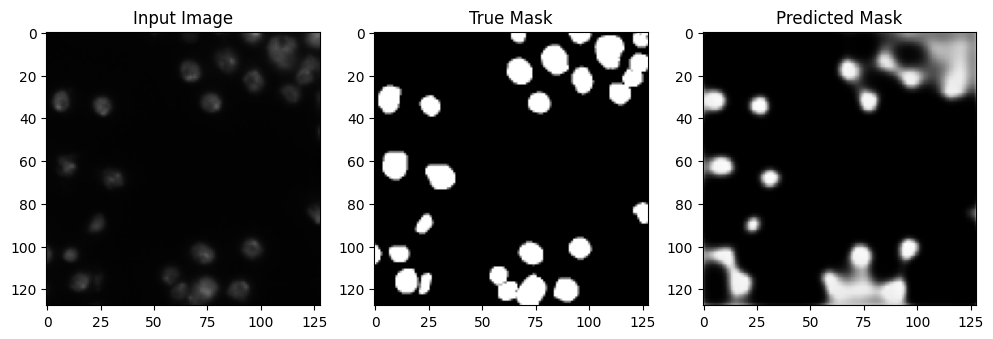

In [16]:
index = 0
pred = segnet_model.predict(X_test[index:index+1])[0]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Input Image")
plt.imshow(X_test[index])

plt.subplot(1,3,2)
plt.title("True Mask")
plt.imshow(Y_test[index].squeeze(), cmap="gray")

plt.subplot(1,3,3)
plt.title("Predicted Mask")
plt.imshow(pred.squeeze(), cmap="gray")

plt.show()

**Save SegNet Model**

In [17]:
segnet_model.save("/content/drive/MyDrive/segnet_model.h5")
print("SegNet Model Saved Successfully!")

SegNet Model Saved Successfully!
